# Optimization of a Multi-Stage Fuel Supply Chain under Operational and Market Constraints

**Course:** MATH 535 — Optimization I  
**Student:** Ignacio Conde  
**Implementation:** Python + PuLP  

This notebook formulates and solves a multi-stage fuel distribution problem inspired by the Zamunda fuel distribution case. The model combines the linear optimization ideas studied in class with a realistic supply chain setting: crude oil is shipped from ports to refineries, converted into gasoline, and then distributed through intermediate warehouses to final demand nodes.

> **Important modeling note.** The core transportation and flow-balance structure is a linear programming model. The fixed refinery-opening costs and company-assignment decisions require binary variables, so the final implementation is a **Mixed-Integer Linear Programming (MILP)** extension. This is useful to mention in the final report: the MILP formulation extends the linear programming material covered in class in order to represent realistic fixed-cost and route-assignment decisions.

## 1. Mathematical Formulation

### Sets

- $P$: ports supplying crude oil.
- $R$: refineries converting crude oil into gasoline.
- $I$: intermediate warehouses.
- $F$: final warehouses.
- $C$: logistics companies, when private transport is considered.

## Main Decision Variables

- $x_{p,r} \geq 0$: crude oil shipped from port $p \in P$ to refinery $r \in R$.
- $y_{r,i} \geq 0$: gasoline shipped from refinery $r \in R$ to intermediate warehouse $i \in I$.
- $z_{i,f} \geq 0$: gasoline shipped from intermediate warehouse $i \in I$ to final warehouse $f \in F$.
- $\delta_r \in \{0,1\}$: 1 if refinery $r$ is activated; 0 otherwise.
- $\mu_{a,c} \in \{0,1\}$: 1 if gasoline route $a$ is assigned to company $c$; 0 otherwise.

---

## Objective Function

The objective is to minimize the total system cost, including crude oil transportation, refinery fixed costs, variable refining costs, gasoline transportation costs, and possible company bonuses.

$$
\min Z =
\sum_{p \in P} \sum_{r \in R} c^{crude}_{p,r} x_{p,r}
+
\sum_{r \in R} F_r \delta_r
+
\sum_{p \in P} \sum_{r \in R} c^{ref}_r x_{p,r}
+
\sum_{r \in R} \sum_{i \in I} c^{gas}_{r,i} y_{r,i}
+
\sum_{i \in I} \sum_{f \in F} c^{gas}_{i,f} z_{i,f}
-
\sum_{a \in A} b_a \mu_{a,\text{Company 1}}
$$

where:

- $c^{crude}_{p,r}$ is the unit cost of transporting crude oil from port $p$ to refinery $r$.
- $F_r$ is the fixed operating cost of refinery $r$.
- $c^{ref}_r$ is the variable refining cost per kiloliter of crude oil processed at refinery $r$.
- $c^{gas}_{r,i}$ is the unit cost of transporting gasoline from refinery $r$ to intermediate warehouse $i$.
- $c^{gas}_{i,f}$ is the unit cost of transporting gasoline from intermediate warehouse $i$ to final warehouse $f$.
- $b_a$ is the bonus applied when route $a$ is assigned to Company 1.
- $A$ is the set of gasoline transportation routes eligible for company assignment.

In the base model, the company assignment term is omitted and the original gasoline transportation costs are used.

---

## Core Constraints

### 1. Crude Oil Supply Constraint

Total crude oil shipped from each port cannot exceed its available supply.

$$
\sum_{r \in R} x_{p,r} \leq S_p
\qquad \forall p \in P
$$

where $S_p$ is the crude oil supply available at port $p$.

---

### 2. Total Crude Oil Availability Constraint

The total amount of crude oil used cannot exceed the maximum monthly crude oil availability.

$$
\sum_{p \in P} \sum_{r \in R} x_{p,r} \leq S^{max}
$$

---

### 3. Refinery Activation Constraints

A refinery can only receive crude oil if it is activated.

$$
\sum_{p \in P} x_{p,r} \leq M \delta_r
\qquad \forall r \in R
$$

To avoid activating a refinery with zero flow, the model can also impose:

$$
\sum_{p \in P} x_{p,r} \geq \epsilon \delta_r
\qquad \forall r \in R
$$

where $M$ is a sufficiently large upper bound and $\epsilon$ is a small positive minimum-flow threshold.

---

### 4. Crude-to-Gasoline Conversion Constraint

Every 3 kiloliters of crude oil produce 1 kiloliter of gasoline. Therefore, gasoline output from each refinery must equal one third of the crude oil processed there.

$$
\sum_{i \in I} y_{r,i}
=
\frac{1}{3}
\sum_{p \in P} x_{p,r}
\qquad \forall r \in R
$$

---

### 5. Intermediate Warehouse Flow Balance

For each intermediate warehouse, total gasoline inflow must equal total gasoline outflow.

$$
\sum_{r \in R} y_{r,i}
=
\sum_{f \in F} z_{i,f}
\qquad \forall i \in I
$$

---

### 6. Final Demand Satisfaction

Each final warehouse must receive exactly its required gasoline demand.

$$
\sum_{i \in I} z_{i,f}
=
D_f
\qquad \forall f \in F
$$

where $D_f$ is the gasoline demand at final warehouse $f$.

---

## Scenario-Specific Constraints

### Scenario 1: Refinery Shutdown

If refinery $w$ is closed, it cannot be activated, receive crude oil, or ship gasoline.

$$
\delta_w = 0
$$

$$
x_{p,w} = 0
\qquad \forall p \in P
$$

$$
y_{w,i} = 0
\qquad \forall i \in I
$$

---

### Scenario 2: Port C Supply Limitation

If port $C$ is limited to 1,500 kiloliters of crude oil, then:

$$
\sum_{r \in R} x_{C,r} \leq 1500
$$

---

### Scenario 3: Demand Shock

If demand increases by a percentage $\alpha$, final demand becomes:

$$
D_f^{shock} = (1+\alpha)D_f
\qquad \forall f \in F
$$

The demand constraint becomes:

$$
\sum_{i \in I} z_{i,f}
=
D_f^{shock}
\qquad \forall f \in F
$$

---

### Scenario 4: Environmental Emissions Cap

Let $e^{crude}_{p,r}$, $e^{ref}_r$, $e^{gas}_{r,i}$, and $e^{gas}_{i,f}$ be the emissions factors associated with crude transportation, refining, and gasoline transportation. The total emissions must satisfy:

$$
\sum_{p \in P} \sum_{r \in R} e^{crude}_{p,r} x_{p,r}
+
\sum_{p \in P} \sum_{r \in R} e^{ref}_r x_{p,r}
+
\sum_{r \in R} \sum_{i \in I} e^{gas}_{r,i} y_{r,i}
+
\sum_{i \in I} \sum_{f \in F} e^{gas}_{i,f} z_{i,f}
\leq E^{max}
$$

where $E^{max}$ is the maximum allowed emissions level.

---

## Company Assignment Extension

For scenarios involving private gasoline transportation companies, each eligible gasoline route must be assigned to one and only one company.

$$
\sum_{c \in C} \mu_{a,c} = 1
\qquad \forall a \in A
$$

Gasoline flow on route $a$ can only be handled by company $c$ if that company is assigned to the route:

$$
q_{a,c} \leq M \mu_{a,c}
\qquad \forall a \in A,\ c \in C
$$

The total gasoline flow on each route is the sum of company-specific flows:

$$
q_a = \sum_{c \in C} q_{a,c}
\qquad \forall a \in A
$$

If all routes must be assigned to a single company, introduce a binary variable $\theta_c$ equal to 1 if company $c$ is selected:

$$
\sum_{c \in C} \theta_c = 1
$$

$$
\mu_{a,c} = \theta_c
\qquad \forall a \in A,\ c \in C
$$

If routes can be assigned one by one, the model only uses:

$$
\sum_{c \in C} \mu_{a,c} = 1
\qquad \forall a \in A
$$

In [12]:
# 2. Imports and global display settings

import math
from copy import deepcopy
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

import pulp
from IPython.display import display, Markdown

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

In [13]:
# 3. Input data

# --------------------------
# Network sets
# --------------------------
PORTS = ["A", "B", "C"]
REFINERIES = ["u", "v", "w"]
INTERMEDIATE = ["1", "2", "3"]
FINAL = ["4", "5"]
COMPANIES = ["Company 1", "Company 2"]

# Gasoline arcs: refineries -> intermediate warehouses, and intermediate -> final warehouses.
GAS_ARCS_RI = [(r, i) for r in REFINERIES for i in INTERMEDIATE]
GAS_ARCS_IF = [(i, f) for i in INTERMEDIATE for f in FINAL]
GAS_ARCS = GAS_ARCS_RI + GAS_ARCS_IF

# --------------------------
# Demand data [kl of gasoline]
# Warehouses 1,2,3 are intermediate warehouses but also have local gasoline demand.
# Warehouses 4,5 are final demand nodes.
# --------------------------
BASE_DEMAND = {
    "1": 400,
    "2": 300,
    "3": 150,
    "4": 250,
    "5": 100,
}

# --------------------------
# Crude oil availability and conversion
# K = 3 means 3 kl of crude oil produce 1 kl of gasoline.
# --------------------------
CRUDE_MAX = 3600
K = 3

# --------------------------
# Crude transport cost [k€/kl]
# --------------------------
CRUDE_COST = {
    ("A", "u"): 0.4, ("A", "v"): 0.7, ("A", "w"): 1.1,
    ("B", "u"): 0.2, ("B", "v"): 0.3, ("B", "w"): 0.5,
    ("C", "u"): 1.3, ("C", "v"): 0.6, ("C", "w"): 0.1,
}

# --------------------------
# Refinery fixed and variable costs
# Fixed cost: [k€]
# Variable refining cost: [k€/kl of crude oil]
# --------------------------
FIXED_COST = {"u": 400, "v": 300, "w": 600}
REFINING_COST = {"u": 0.2, "v": 0.4, "w": 0.1}

# --------------------------
# Base gasoline transport cost [k€/kl]
# --------------------------
BASE_GAS_COST = {
    ("u", "1"): 0.6, ("u", "2"): 2.4, ("u", "3"): 4.5,
    ("v", "1"): 2.7, ("v", "2"): 1.8, ("v", "3"): 2.7,
    ("w", "1"): 5.4, ("w", "2"): 3.0, ("w", "3"): 1.5,
    ("1", "4"): 2.1, ("1", "5"): 3.0,
    ("2", "4"): 3.6, ("2", "5"): 0.6,
    ("3", "4"): 1.5, ("3", "5"): 1.5,
}

# --------------------------
# Gasoline transport costs under private companies [k€/kl]
# These values reproduce the two-company scenario from the original case.
# --------------------------
COMPANY_GAS_COST = {
    "Company 1": {
        ("u", "1"): 1.80, ("u", "2"): 3.30, ("u", "3"): 4.85,
        ("v", "1"): 3.15, ("v", "2"): 2.85, ("v", "3"): 3.15,
        ("w", "1"): 4.65, ("w", "2"): 3.15, ("w", "3"): 2.85,
        ("1", "4"): 2.65, ("1", "5"): 3.15,
        ("2", "4"): 2.95, ("2", "5"): 2.25,
        ("3", "4"): 2.85, ("3", "5"): 2.85,
    },
    "Company 2": {
        ("u", "1"): 2.15, ("u", "2"): 2.70, ("u", "3"): 3.48,
        ("v", "1"): 3.15, ("v", "2"): 2.15, ("v", "3"): 2.65,
        ("w", "1"): 2.95, ("w", "2"): 2.40, ("w", "3"): 2.70,
        ("1", "4"): 3.00, ("1", "5"): 2.48,
        ("2", "4"): 2.70, ("2", "5"): 2.75,
        ("3", "4"): 2.48, ("3", "5"): 2.70,
    },
}

# --------------------------
# Emission factors [proxy kg CO2e per kl shipped/refined]
# These are synthetic but realistic-style coefficients used for the sustainability extension.
# They allow the model to study cost vs. environmental impact trade-offs.
# --------------------------
CRUDE_EMISSIONS = {
    ("A", "u"): 0.40, ("A", "v"): 0.55, ("A", "w"): 0.80,
    ("B", "u"): 0.30, ("B", "v"): 0.35, ("B", "w"): 0.50,
    ("C", "u"): 0.90, ("C", "v"): 0.65, ("C", "w"): 0.25,
}
REFINING_EMISSIONS = {"u": 0.50, "v": 0.70, "w": 0.45}
GAS_EMISSIONS = {
    ("u", "1"): 0.20, ("u", "2"): 0.35, ("u", "3"): 0.55,
    ("v", "1"): 0.45, ("v", "2"): 0.30, ("v", "3"): 0.40,
    ("w", "1"): 0.70, ("w", "2"): 0.50, ("w", "3"): 0.25,
    ("1", "4"): 0.30, ("1", "5"): 0.45,
    ("2", "4"): 0.50, ("2", "5"): 0.20,
    ("3", "4"): 0.25, ("3", "5"): 0.25,
}

In [14]:
# 4. Helper functions for clean outputs

def nonzero_records(var_dict, index_names, value_name="Value", tol=1e-6):
    """Convert a PuLP variable dictionary into a clean DataFrame of nonzero values."""
    rows = []
    for key, var in var_dict.items():
        val = pulp.value(var)
        if val is not None and abs(val) > tol:
            if not isinstance(key, tuple):
                key = (key,)
            rows.append({**dict(zip(index_names, key)), value_name: val})
    return pd.DataFrame(rows).sort_values(index_names).reset_index(drop=True) if rows else pd.DataFrame(columns=index_names + [value_name])


def format_k(value):
    """Format values expressed in k€."""
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return "n/a"
    return f"{value:,.2f} k€"


def safe_value(x):
    """Safely extract a numeric value from a PuLP expression."""
    v = pulp.value(x)
    return 0.0 if v is None else float(v)

## 5. Model Builder

The following function creates and solves the optimization model. It is intentionally written as a reusable function so that each scenario only modifies a small number of parameters or adds a small number of constraints.

The function supports three transportation-market structures:

1. `company_mode=None`: original public/base gasoline transportation costs.
2. `company_mode="single_company"`: all gasoline routes must be assigned to one company.
3. `company_mode="route_by_route"`: every gasoline route can be assigned individually, but each route must be served by exactly one company.

In [15]:
# 5. Model builder and solver

def solve_fuel_model(
    scenario_name,
    demand=None,
    crude_max=CRUDE_MAX,
    crude_cost=None,
    base_gas_cost=None,
    company_gas_cost=None,
    refining_cost=None,
    fixed_cost=None,
    closed_refineries=None,
    port_limits=None,
    company_mode=None,
    bonus_company1=0.0,
    gas_cost_multiplier=1.0,
    crude_cost_multiplier=1.0,
    max_emissions=None,
    msg=False,
):
    """
    Build and solve the fuel supply chain optimization model.

    Parameters
    ----------
    scenario_name : str
        Name used in output tables and plots.
    demand : dict
        Gasoline demand at warehouses 1,2,3,4,5 [kl].
    crude_max : float
        Maximum crude oil available [kl].
    closed_refineries : list[str]
        Refineries forced to be unavailable.
    port_limits : dict
        Optional maximum crude shipped from selected ports, e.g. {"C": 1500}.
    company_mode : None, "single_company", or "route_by_route"
        Defines how gasoline transportation costs and assignments are modeled.
    bonus_company1 : float
        Fixed bonus [k€] subtracted for each route assigned to Company 1.
    max_emissions : float or None
        Optional upper bound on total proxy emissions.
    msg : bool
        Whether the PuLP CBC solver should print logs.
    """
    demand = deepcopy(BASE_DEMAND if demand is None else demand)
    crude_cost = deepcopy(CRUDE_COST if crude_cost is None else crude_cost)
    base_gas_cost = deepcopy(BASE_GAS_COST if base_gas_cost is None else base_gas_cost)
    company_gas_cost = deepcopy(COMPANY_GAS_COST if company_gas_cost is None else company_gas_cost)
    refining_cost = deepcopy(REFINING_COST if refining_cost is None else refining_cost)
    fixed_cost = deepcopy(FIXED_COST if fixed_cost is None else fixed_cost)
    closed_refineries = [] if closed_refineries is None else list(closed_refineries)
    port_limits = {} if port_limits is None else dict(port_limits)

    # Cost multipliers for scenario analysis.
    crude_cost = {k: v * crude_cost_multiplier for k, v in crude_cost.items()}
    base_gas_cost = {k: v * gas_cost_multiplier for k, v in base_gas_cost.items()}
    company_gas_cost = {
        c: {arc: cost * gas_cost_multiplier for arc, cost in company_gas_cost[c].items()}
        for c in COMPANIES
    }

    # Big-M chosen as total gasoline demand. No single gasoline arc needs more than this.
    total_gas_demand = sum(demand.values())
    big_m_gas = total_gas_demand

    # --------------------------
    # Create model
    # --------------------------
    model = pulp.LpProblem(f"Fuel_Distribution_{scenario_name}", pulp.LpMinimize)

    # --------------------------
    # Decision variables
    # --------------------------
    x = pulp.LpVariable.dicts(
        "crude_flow", [(p, r) for p in PORTS for r in REFINERIES], lowBound=0, cat="Continuous"
    )
    delta = pulp.LpVariable.dicts("refinery_active", REFINERIES, lowBound=0, upBound=1, cat="Binary")

    # Gasoline flow variables differ depending on whether private companies are modeled.
    if company_mode is None:
        q = pulp.LpVariable.dicts("gasoline_flow", GAS_ARCS, lowBound=0, cat="Continuous")
        assign = None
        single_company = None
    else:
        q = pulp.LpVariable.dicts(
            "gasoline_flow", [(arc[0], arc[1], c) for arc in GAS_ARCS for c in COMPANIES],
            lowBound=0,
            cat="Continuous",
        )
        assign = pulp.LpVariable.dicts(
            "route_assigned", [(arc[0], arc[1], c) for arc in GAS_ARCS for c in COMPANIES],
            lowBound=0,
            upBound=1,
            cat="Binary",
        )
        single_company = pulp.LpVariable.dicts("single_company", COMPANIES, lowBound=0, upBound=1, cat="Binary")

    # --------------------------
    # Cost components
    # --------------------------
    crude_transport_cost = pulp.lpSum(crude_cost[p, r] * x[p, r] for p in PORTS for r in REFINERIES)
    refining_variable_cost = pulp.lpSum(refining_cost[r] * x[p, r] for p in PORTS for r in REFINERIES)
    refining_fixed_cost = pulp.lpSum(fixed_cost[r] * delta[r] for r in REFINERIES)

    if company_mode is None:
        gasoline_transport_cost = pulp.lpSum(base_gas_cost[arc] * q[arc] for arc in GAS_ARCS)
        bonus_value = 0
    else:
        gasoline_transport_cost = pulp.lpSum(
            company_gas_cost[c][arc] * q[arc[0], arc[1], c]
            for arc in GAS_ARCS for c in COMPANIES
        )
        bonus_value = pulp.lpSum(
            bonus_company1 * assign[arc[0], arc[1], "Company 1"]
            for arc in GAS_ARCS
        )

    total_cost = crude_transport_cost + refining_variable_cost + refining_fixed_cost + gasoline_transport_cost - bonus_value
    model += total_cost, "Total_System_Cost"

    # --------------------------
    # Core constraints
    # --------------------------

    # Total crude availability.
    model += pulp.lpSum(x[p, r] for p in PORTS for r in REFINERIES) <= crude_max, "total_crude_availability"

    # Optional port-specific limits.
    for p, limit in port_limits.items():
        model += pulp.lpSum(x[p, r] for r in REFINERIES) <= limit, f"port_{p}_limit"

    # Refinery activation: if delta[r] = 0, no crude can enter refinery r.
    for r in REFINERIES:
        model += pulp.lpSum(x[p, r] for p in PORTS) <= crude_max * delta[r], f"activation_upper_{r}"

    # Closed refineries: force zero activation and zero incoming crude.
    for r in closed_refineries:
        model += delta[r] == 0, f"closed_refinery_{r}"
        for p in PORTS:
            model += x[p, r] == 0, f"no_crude_to_closed_{p}_{r}"

    # Helper expressions for total gasoline flow on an arc, regardless of company mode.
    def gas_flow(arc):
        if company_mode is None:
            return q[arc]
        return pulp.lpSum(q[arc[0], arc[1], c] for c in COMPANIES)

    # Refinery balance: gasoline leaving each refinery equals crude input divided by K.
    for r in REFINERIES:
        model += (
            pulp.lpSum(x[p, r] for p in PORTS) / K
            == pulp.lpSum(gas_flow((r, i)) for i in INTERMEDIATE)
        ), f"refinery_balance_{r}"

    # Intermediate warehouse balance: inflow = local demand + outflow to final warehouses.
    for i in INTERMEDIATE:
        model += (
            pulp.lpSum(gas_flow((r, i)) for r in REFINERIES)
            == demand[i] + pulp.lpSum(gas_flow((i, f)) for f in FINAL)
        ), f"intermediate_balance_{i}"

    # Final demand satisfaction.
    for f in FINAL:
        model += (
            pulp.lpSum(gas_flow((i, f)) for i in INTERMEDIATE) == demand[f]
        ), f"final_demand_{f}"

    # Company assignment constraints.
    if company_mode == "single_company":
        # Exactly one company is selected for the entire gasoline network.
        model += pulp.lpSum(single_company[c] for c in COMPANIES) == 1, "choose_one_company"
        for arc in GAS_ARCS:
            for c in COMPANIES:
                model += assign[arc[0], arc[1], c] == single_company[c], f"single_company_assignment_{arc[0]}_{arc[1]}_{c}"
                model += q[arc[0], arc[1], c] <= big_m_gas * assign[arc[0], arc[1], c], f"flow_link_{arc[0]}_{arc[1]}_{c}"

    elif company_mode == "route_by_route":
        # Every route is assigned to exactly one company. Flow can only use the assigned company.
        for arc in GAS_ARCS:
            model += pulp.lpSum(assign[arc[0], arc[1], c] for c in COMPANIES) == 1, f"one_company_per_route_{arc[0]}_{arc[1]}"
            for c in COMPANIES:
                model += q[arc[0], arc[1], c] <= big_m_gas * assign[arc[0], arc[1], c], f"flow_link_{arc[0]}_{arc[1]}_{c}"

    elif company_mode is not None:
        raise ValueError("company_mode must be None, 'single_company', or 'route_by_route'.")

    # Environmental extension: optional emissions cap.
    crude_emissions_expr = pulp.lpSum(CRUDE_EMISSIONS[p, r] * x[p, r] for p in PORTS for r in REFINERIES)
    refining_emissions_expr = pulp.lpSum(REFINING_EMISSIONS[r] * x[p, r] for p in PORTS for r in REFINERIES)
    gas_emissions_expr = pulp.lpSum(GAS_EMISSIONS[arc] * gas_flow(arc) for arc in GAS_ARCS)
    total_emissions_expr = crude_emissions_expr + refining_emissions_expr + gas_emissions_expr

    if max_emissions is not None:
        model += total_emissions_expr <= max_emissions, "emissions_cap"

    # --------------------------
    # Solve
    # --------------------------
    solver = pulp.PULP_CBC_CMD(msg=msg)
    model.solve(solver)

    status = pulp.LpStatus[model.status]

    # --------------------------
    # Extract results
    # --------------------------
    if status == "Optimal":
        crude_df = nonzero_records(x, ["Port", "Refinery"], "Crude flow [kl]")
        active_refineries_df = pd.DataFrame({
            "Refinery": REFINERIES,
            "Active": [safe_value(delta[r]) for r in REFINERIES],
            "Crude input [kl]": [sum(safe_value(x[p, r]) for p in PORTS) for r in REFINERIES],
            "Gasoline output [kl]": [sum(safe_value(x[p, r]) for p in PORTS) / K for r in REFINERIES],
        })

        if company_mode is None:
            gas_df = nonzero_records(q, ["From", "To"], "Gasoline flow [kl]")
            assignment_df = pd.DataFrame()
        else:
            gas_df = nonzero_records(q, ["From", "To", "Company"], "Gasoline flow [kl]")
            assignment_df = nonzero_records(assign, ["From", "To", "Company"], "Assigned")

        costs = {
            "Scenario": scenario_name,
            "Status": status,
            "Objective [k€]": safe_value(total_cost),
            "Crude transport [k€]": safe_value(crude_transport_cost),
            "Refining variable [k€]": safe_value(refining_variable_cost),
            "Refining fixed [k€]": safe_value(refining_fixed_cost),
            "Gasoline transport [k€]": safe_value(gasoline_transport_cost),
            "Company 1 bonus [k€]": safe_value(bonus_value),
            "Total emissions [proxy units]": safe_value(total_emissions_expr),
        }
    else:
        crude_df = pd.DataFrame()
        gas_df = pd.DataFrame()
        active_refineries_df = pd.DataFrame()
        assignment_df = pd.DataFrame()
        costs = {
            "Scenario": scenario_name,
            "Status": status,
            "Objective [k€]": np.nan,
            "Crude transport [k€]": np.nan,
            "Refining variable [k€]": np.nan,
            "Refining fixed [k€]": np.nan,
            "Gasoline transport [k€]": np.nan,
            "Company 1 bonus [k€]": np.nan,
            "Total emissions [proxy units]": np.nan,
        }

    return {
        "scenario": scenario_name,
        "status": status,
        "model": model,
        "costs": costs,
        "crude_df": crude_df,
        "gas_df": gas_df,
        "active_refineries_df": active_refineries_df,
        "assignment_df": assignment_df,
        "company_mode": company_mode,
    }

## 6. Visualization Functions

These functions generate:

1. A network diagram showing the physical structure of the optimization system.
2. Scenario-specific flow diagrams with only the arcs used in the optimal solution.
3. Cost comparison charts across scenarios.
4. A model-structure heatmap showing how the main variable blocks connect to each constraint family.

In [16]:
# 6. Visualization functions

def draw_network_template(title="Fuel Supply Chain Network Structure"):
    """Draw the full network structure without optimized flow values."""
    G = nx.DiGraph()

    layers = {
        "Ports": PORTS,
        "Refineries": REFINERIES,
        "Intermediate Warehouses": INTERMEDIATE,
        "Final Warehouses": FINAL,
    }
    positions = {}
    x_pos = {"Ports": 0, "Refineries": 1, "Intermediate Warehouses": 2, "Final Warehouses": 3}

    for layer, nodes in layers.items():
        for idx, node in enumerate(nodes):
            G.add_node(node, layer=layer)
            positions[node] = (x_pos[layer], -idx)

    for p in PORTS:
        for r in REFINERIES:
            G.add_edge(p, r)
    for r in REFINERIES:
        for i in INTERMEDIATE:
            G.add_edge(r, i)
    for i in INTERMEDIATE:
        for f in FINAL:
            G.add_edge(i, f)

    plt.figure(figsize=(11, 6))
    nx.draw_networkx_nodes(G, positions, node_size=2200)
    nx.draw_networkx_labels(G, positions, font_size=10)
    nx.draw_networkx_edges(G, positions, arrows=True, arrowstyle="->", width=1.2)
    plt.title(title)
    plt.axis("off")
    plt.show()


def draw_solution_network(result, min_flow=1e-6):
    """Draw only the arcs carrying positive flow in a solved scenario."""
    scenario = result["scenario"]
    crude_df = result["crude_df"]
    gas_df = result["gas_df"]

    G = nx.DiGraph()
    positions = {}
    for idx, p in enumerate(PORTS):
        G.add_node(p)
        positions[p] = (0, -idx)
    for idx, r in enumerate(REFINERIES):
        G.add_node(r)
        positions[r] = (1, -idx)
    for idx, i in enumerate(INTERMEDIATE):
        G.add_node(i)
        positions[i] = (2, -idx)
    for idx, f in enumerate(FINAL):
        G.add_node(f)
        positions[f] = (3, -idx - 0.5)

    edge_labels = {}
    widths = []

    if not crude_df.empty:
        for _, row in crude_df.iterrows():
            flow = row["Crude flow [kl]"]
            if flow > min_flow:
                edge = (row["Port"], row["Refinery"])
                G.add_edge(*edge)
                edge_labels[edge] = f"{flow:.0f} kl crude"

    if not gas_df.empty:
        if "Company" in gas_df.columns:
            grouped = gas_df.groupby(["From", "To"], as_index=False)["Gasoline flow [kl]"].sum()
        else:
            grouped = gas_df.copy()
        for _, row in grouped.iterrows():
            flow = row["Gasoline flow [kl]"]
            if flow > min_flow:
                edge = (row["From"], row["To"])
                G.add_edge(*edge)
                edge_labels[edge] = f"{flow:.0f} kl gas"

    max_flow = 1
    all_flows = []
    for label in edge_labels.values():
        try:
            all_flows.append(float(label.split()[0]))
        except Exception:
            pass
    if all_flows:
        max_flow = max(all_flows)

    for edge in G.edges:
        label = edge_labels.get(edge, "0")
        flow = float(label.split()[0]) if label else 0
        widths.append(1.0 + 4.0 * flow / max_flow)

    plt.figure(figsize=(12, 6))
    nx.draw_networkx_nodes(G, positions, node_size=2200)
    nx.draw_networkx_labels(G, positions, font_size=10)
    nx.draw_networkx_edges(G, positions, arrows=True, arrowstyle="->", width=widths)
    nx.draw_networkx_edge_labels(G, positions, edge_labels=edge_labels, font_size=8)
    plt.title(f"Optimal Flow Network — {scenario}")
    plt.axis("off")
    plt.show()


def plot_objective_comparison(results):
    """Compare objective values across solved scenarios."""
    summary = pd.DataFrame([r["costs"] for r in results])
    summary = summary[summary["Status"] == "Optimal"].copy()
    if summary.empty:
        print("No optimal scenarios to plot.")
        return

    plt.figure(figsize=(12, 5))
    plt.bar(summary["Scenario"], summary["Objective [k€]"])
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("Objective value [k€]")
    plt.title("Objective Function Comparison by Scenario")
    plt.tight_layout()
    plt.show()


def plot_cost_breakdown(results):
    """Stacked cost component comparison across scenarios."""
    summary = pd.DataFrame([r["costs"] for r in results])
    summary = summary[summary["Status"] == "Optimal"].copy()
    if summary.empty:
        print("No optimal scenarios to plot.")
        return

    components = [
        "Crude transport [k€]",
        "Refining variable [k€]",
        "Refining fixed [k€]",
        "Gasoline transport [k€]",
    ]
    bottom = np.zeros(len(summary))
    plt.figure(figsize=(12, 6))
    for comp in components:
        plt.bar(summary["Scenario"], summary[comp], bottom=bottom, label=comp)
        bottom += summary[comp].values

    # Show bonus as a separate negative marker when applicable.
    if summary["Company 1 bonus [k€]"].abs().sum() > 0:
        plt.scatter(summary["Scenario"], summary["Objective [k€]"], marker="o", label="Net objective after bonus")

    plt.xticks(rotation=35, ha="right")
    plt.ylabel("Cost [k€]")
    plt.title("Cost Breakdown by Scenario")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_emissions_vs_cost(results):
    """Scatter plot of cost vs. proxy emissions."""
    summary = pd.DataFrame([r["costs"] for r in results])
    summary = summary[summary["Status"] == "Optimal"].copy()
    if summary.empty:
        print("No optimal scenarios to plot.")
        return

    plt.figure(figsize=(8, 6))
    plt.scatter(summary["Total emissions [proxy units]"], summary["Objective [k€]"])
    for _, row in summary.iterrows():
        plt.annotate(row["Scenario"], (row["Total emissions [proxy units]"], row["Objective [k€]"]), fontsize=8)
    plt.xlabel("Total emissions [proxy units]")
    plt.ylabel("Objective value [k€]")
    plt.title("Cost vs. Emissions Trade-off")
    plt.tight_layout()
    plt.show()


def plot_model_structure_heatmap():
    """Visual summary of which variable groups appear in which constraint families."""
    rows = [
        "Total crude availability",
        "Port limits",
        "Refinery activation",
        "Refinery balance",
        "Intermediate balance",
        "Final demand",
        "Company assignment",
        "Emissions cap",
    ]
    cols = ["x[p,r]", "delta[r]", "gas flows", "assignment binaries"]
    matrix = np.array([
        [1, 0, 0, 0],
        [1, 0, 0, 0],
        [1, 1, 0, 0],
        [1, 0, 1, 0],
        [0, 0, 1, 0],
        [0, 0, 1, 0],
        [0, 0, 1, 1],
        [1, 0, 1, 0],
    ])

    plt.figure(figsize=(9, 5))
    plt.imshow(matrix, aspect="auto")
    plt.xticks(range(len(cols)), cols, rotation=25, ha="right")
    plt.yticks(range(len(rows)), rows)
    plt.title("Model Structure: Constraint Families vs. Variable Blocks")
    plt.colorbar(label="Variable appears in constraint")
    plt.tight_layout()
    plt.show()

## 7. Baseline Network and Model Structure

Before solving any scenario, we display the physical network and the structure of the mathematical model.

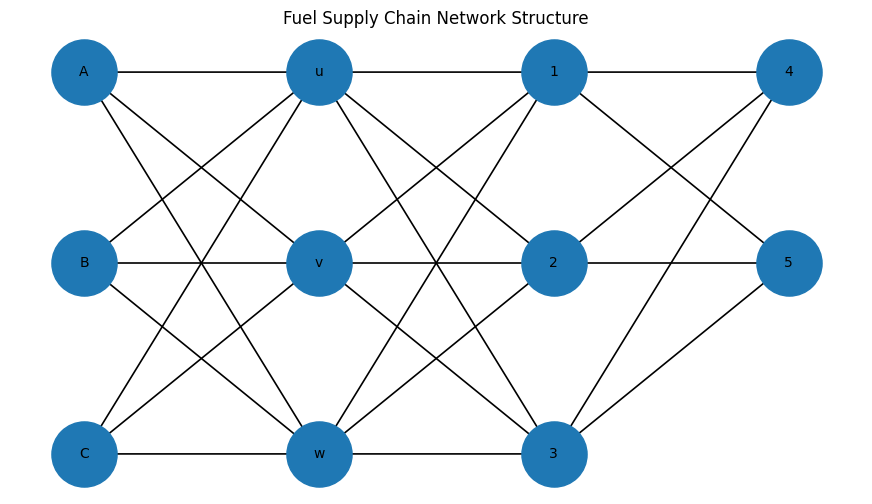

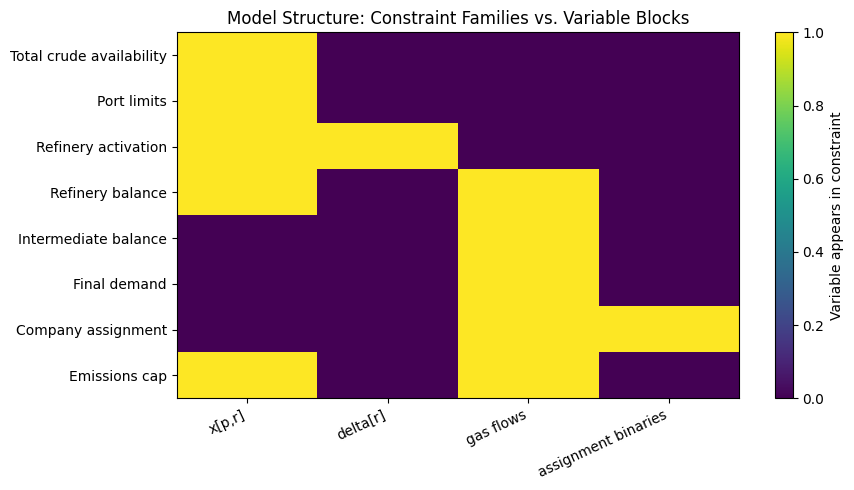

In [17]:
draw_network_template()
plot_model_structure_heatmap()

## 8. Scenario Analysis

The model is solved under several scenarios:

1. **Base case:** all refineries available, original costs.
2. **Refinery shutdown:** refinery `w` is unavailable.
3. **Port C capacity limit:** port `C` can ship at most 1,500 kl of crude oil.
4. **Single private carrier:** all gasoline routes must be served by one logistics company.
5. **Route-by-route privatization:** each gasoline route can be assigned to either company, but no route can be shared.
6. **Company 1 bonus:** same as route-by-route, but Company 1 offers a 100 k€ bonus per assigned route.
7. **Demand shock:** gasoline demand increases by 10%, and emergency crude procurement is allowed.
8. **Transportation cost stress:** gasoline transportation costs increase by 15%.
9. **Environmental constraint:** total emissions are capped relative to the base solution.

In [18]:
# 8. Solve scenarios

results = []

# 1) Base case
base = solve_fuel_model("Base case")
results.append(base)

# 2) Refinery w shutdown
results.append(
    solve_fuel_model("Refinery w shutdown", closed_refineries=["w"])
)

# 3) Port C limited to 1500 kl
results.append(
    solve_fuel_model("Port C limit", port_limits={"C": 1500})
)

# 4) All gasoline routes assigned to one private company
results.append(
    solve_fuel_model("Single private carrier", company_mode="single_company")
)

# 5) Route-by-route company assignment
results.append(
    solve_fuel_model("Route-by-route carriers", company_mode="route_by_route")
)

# 6) Route-by-route assignment with Company 1 bonus
results.append(
    solve_fuel_model("Company 1 bonus", company_mode="route_by_route", bonus_company1=100)
)

# 7) Demand shock: +10% demand, with emergency crude availability adjusted accordingly.
demand_shock = {k: v * 1.10 for k, v in BASE_DEMAND.items()}
results.append(
    solve_fuel_model("Demand +10%", demand=demand_shock, crude_max=CRUDE_MAX * 1.10)
)

# 8) Transportation cost stress: gasoline transport costs increase by 15%.
results.append(
    solve_fuel_model("Gas transport +15%", gas_cost_multiplier=1.15)
)

# 9) Environmental constraint: first use base emissions, then impose a cap.
# If this is infeasible, adjust the cap upward to 99% or 100% for a feasible sensitivity case.
base_emissions = base["costs"]["Total emissions [proxy units]"]
results.append(
    solve_fuel_model("Emissions cap 98%", max_emissions=0.98 * base_emissions)
)

summary_df = pd.DataFrame([r["costs"] for r in results])
summary_df

c:\Users\icros\Desktop\projects\fuel-optimization-project\.venv\Lib\site-packages\pulp\pulp.py:1489: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")
c:\Users\icros\Desktop\projects\fuel-optimization-project\.venv\Lib\site-packages\pulp\pulp.py:1489: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")
c:\Users\icros\Desktop\projects\fuel-optimization-project\.venv\Lib\site-packages\pulp\pulp.py:1489: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")
c:\Users\icros\Desktop\projects\fuel-optimization-project\.venv\Lib\site-packages\pulp\pulp.py:1489: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")
c:\Users\icros\Desktop\proje

,Scenario,Status,Objective [k€],Crude transport [k€],Refining variable [k€],Refining fixed [k€],Gasoline transport [k€],Company 1 bonus [k€],Total emissions [proxy units]
0,Base case,Optimal,4375.00,480.0,480.0,1000.0,2415.00,0.0,3082.50
1,Refinery w shutdown,Optimal,4450.00,720.0,720.0,400.0,2610.00,0.0,3327.50
2,Port C limit,Optimal,4375.00,570.0,570.0,1000.0,2235.00,0.0,3127.50
3,Single private carrier,Optimal,5415.00,360.0,360.0,600.0,4095.00,0.0,3307.50
4,Route-by-route carriers,Optimal,5365.00,360.0,360.0,600.0,4045.00,0.0,3307.50
5,Company 1 bonus,Optimal,4150.00,360.0,360.0,600.0,4130.00,1300.0,3307.50
6,Demand +10%,Optimal,4712.50,627.0,627.0,1000.0,2458.50,0.0,3440.25
7,Gas transport +15%,Optimal,4710.25,570.0,570.0,1000.0,2570.25,0.0,3127.50
8,Emissions cap 98%,Infeasible,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 9. Detailed Results for Each Scenario

Run the next cell to print the optimal crude flows, gasoline flows, active refineries, and company assignments when applicable.

In [19]:
# ==========================================================
# 9. Detailed scenario outputs
# ==========================================================

for result in results:
    display(Markdown(f"## Scenario: {result['scenario']}"))
    display(Markdown(f"**Solver status:** `{result['status']}`"))

    if result["status"] != "Optimal":
        display(Markdown("No optimal solution was found for this scenario. Check feasibility or adjust scenario assumptions."))
        continue

    display(Markdown(f"**Objective value:** {format_k(result['costs']['Objective [k€]'])}"))
    display(Markdown("### Active Refineries"))
    display(result["active_refineries_df"])

    display(Markdown("### Crude Oil Flows"))
    display(result["crude_df"])

    display(Markdown("### Gasoline Flows"))
    display(result["gas_df"])

    if not result["assignment_df"].empty:
        display(Markdown("### Company Assignment"))
        display(result["assignment_df"])

## Scenario: Base case

**Solver status:** `Optimal`

**Objective value:** 4,375.00 k€

### Active Refineries

,Refinery,Active,Crude input [kl],Gasoline output [kl]
0,u,1.0,1200.0,400.0
1,v,0.0,0.0,0.0
2,w,1.0,2400.0,800.0


...

### Gasoline Flows

,From,To,Gasoline flow [kl]
0,3,4,250.0
1,3,5,100.0
2,u,1,400.0
3,u,2,300.0
4,w,3,500.0


## Scenario: Emissions cap 98%

**Solver status:** `Infeasible`

No optimal solution was found for this scenario. Check feasibility or adjust scenario assumptions.

## 10. Visual Comparison Across Scenarios

These charts will be useful for the final report because they make the impact of additional constraints visible:

- The objective comparison shows how each operational or market constraint changes the optimal cost.
- The cost breakdown identifies whether the increase comes from crude transportation, refinery costs, or gasoline distribution.
- The cost-emissions plot supports the sustainability extension.

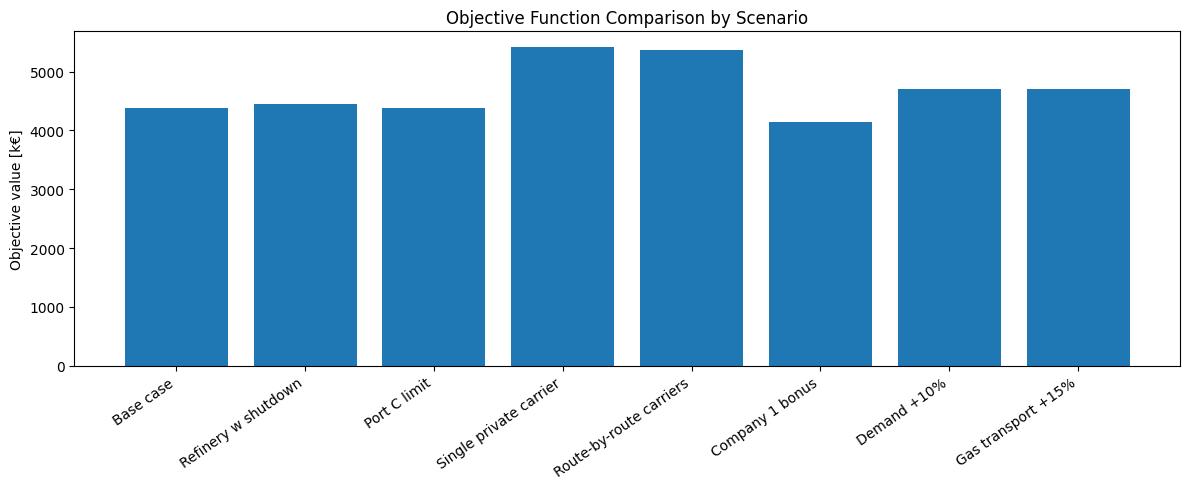

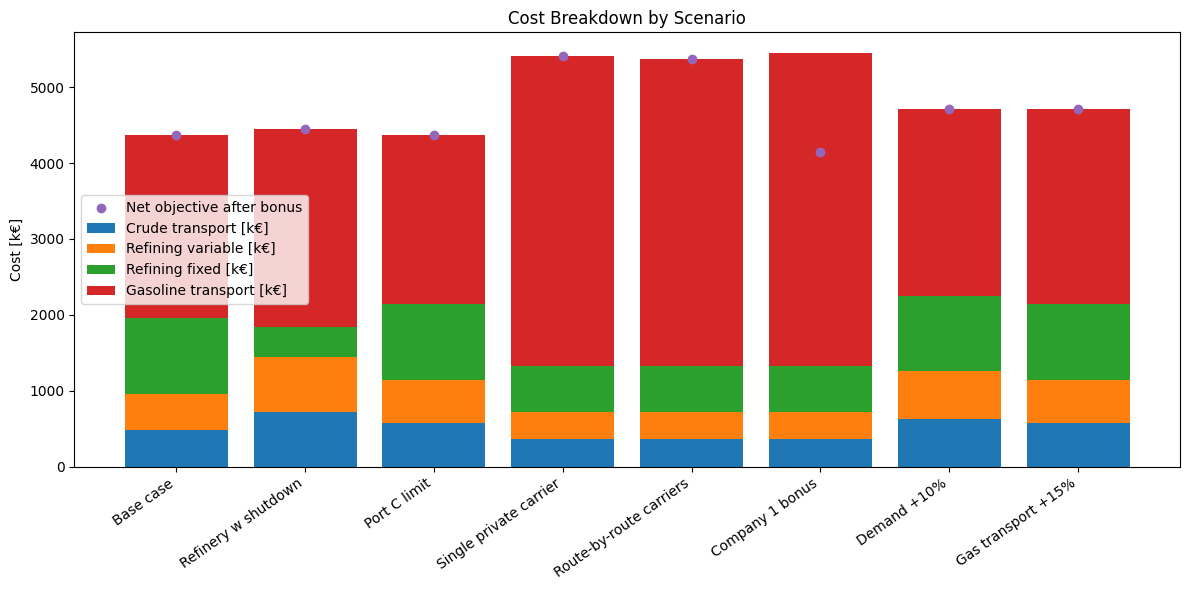

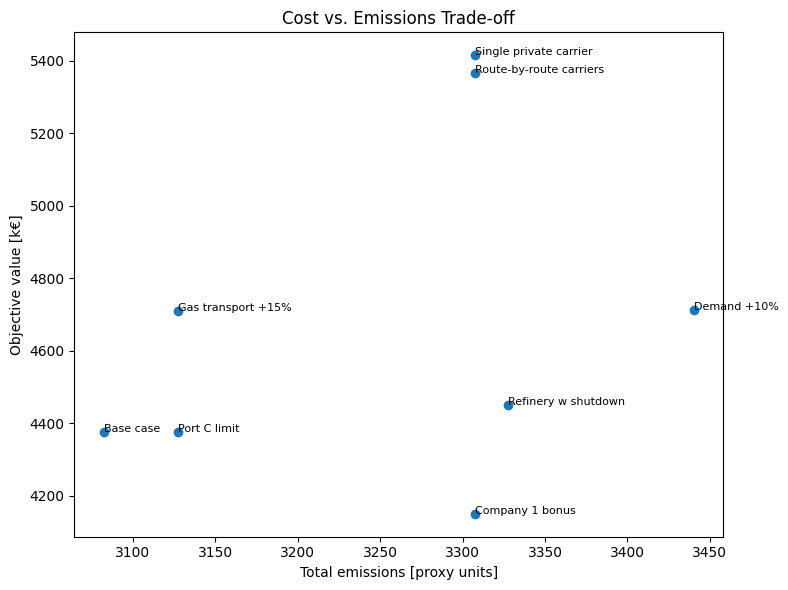

In [20]:
# ==========================================================
# 10. Scenario comparison plots
# ==========================================================

plot_objective_comparison(results)
plot_cost_breakdown(results)
plot_emissions_vs_cost(results)

## 11. Optimal Flow Diagrams

The next cell plots the physical flow pattern for each optimal scenario. These figures are especially useful for the report because they show how the optimization model changes the supply chain structure when additional constraints are added.

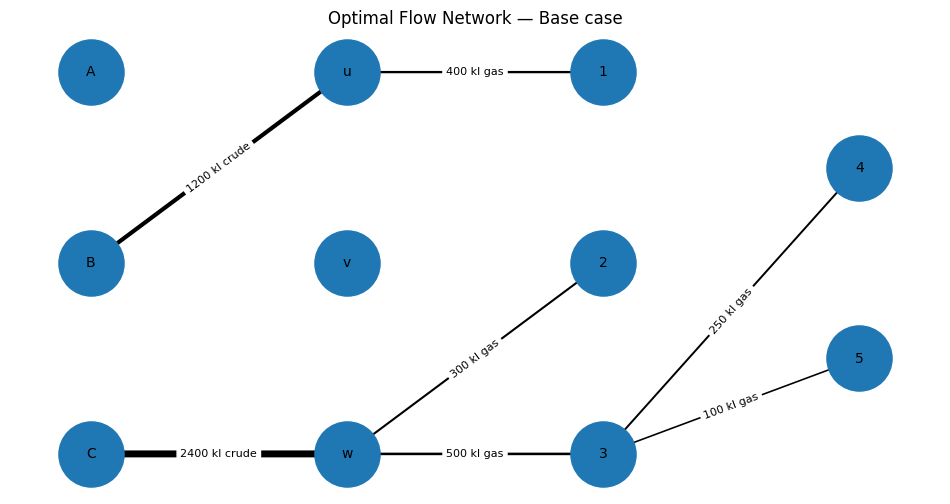

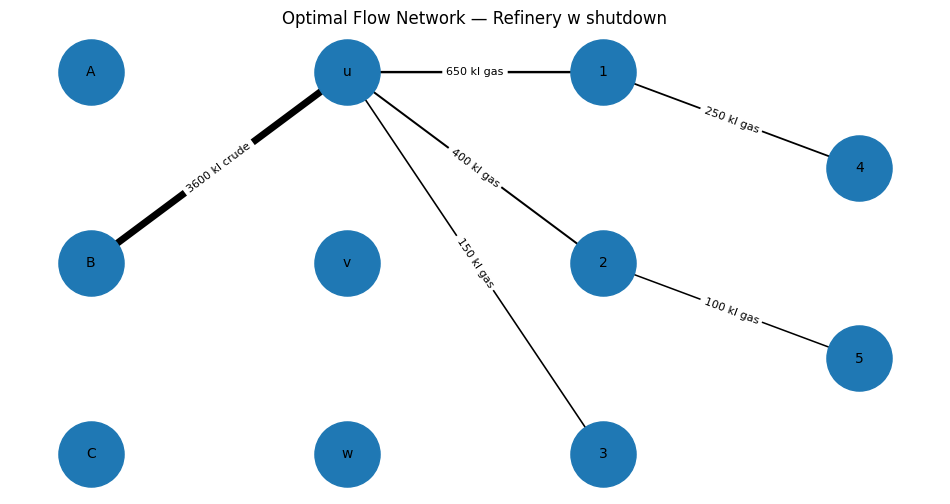

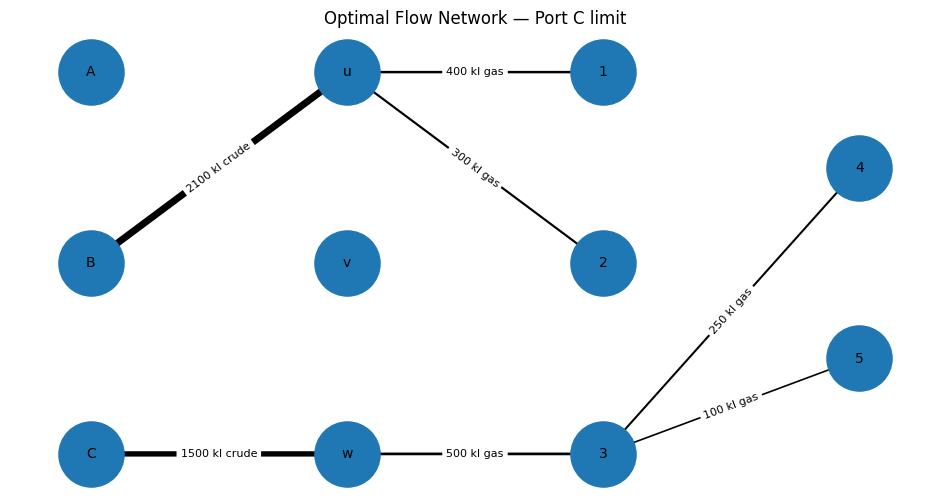

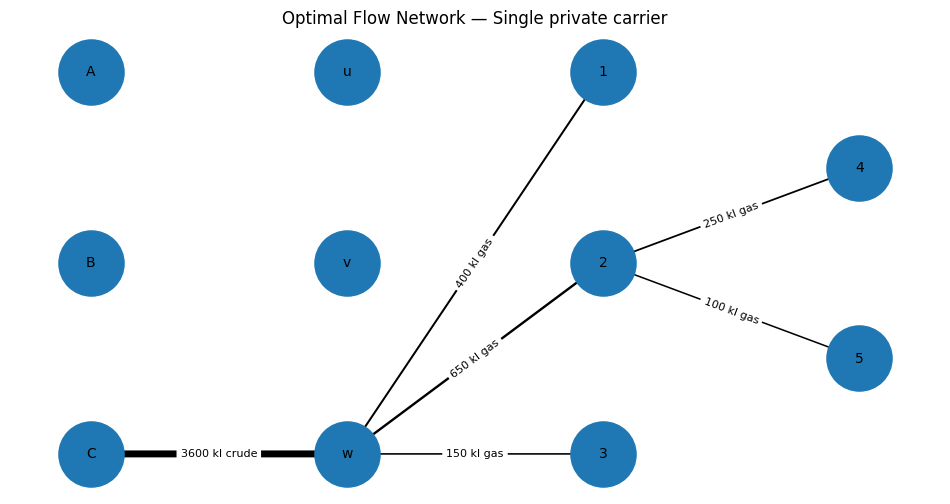

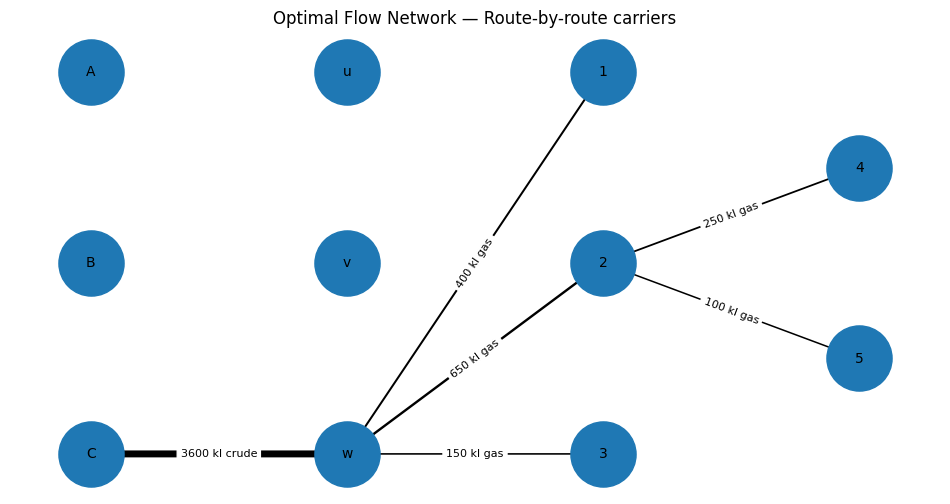

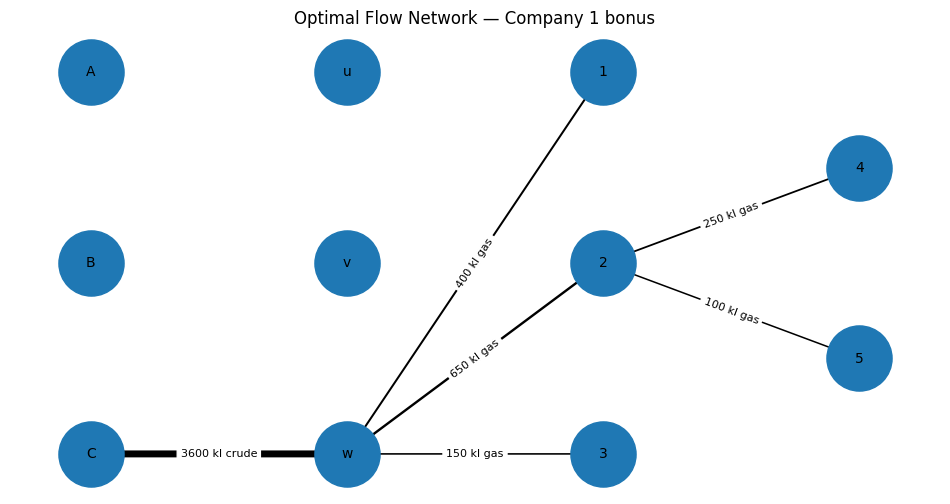

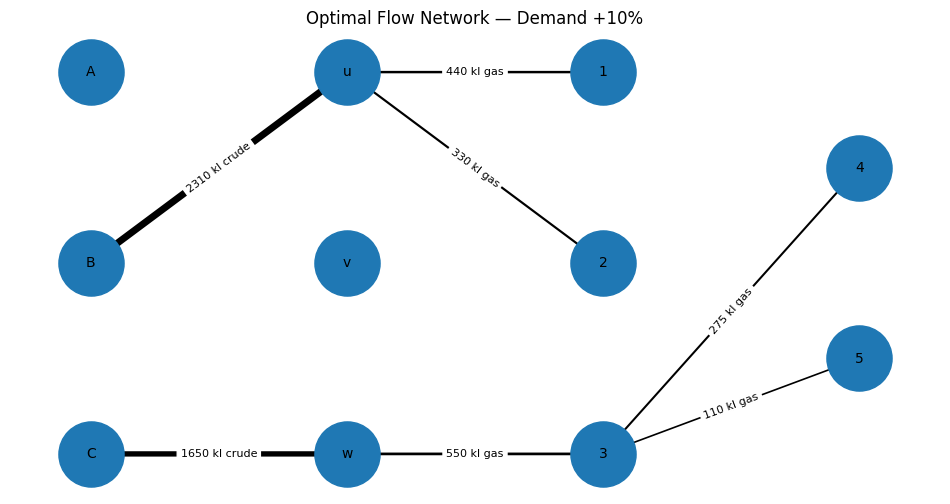

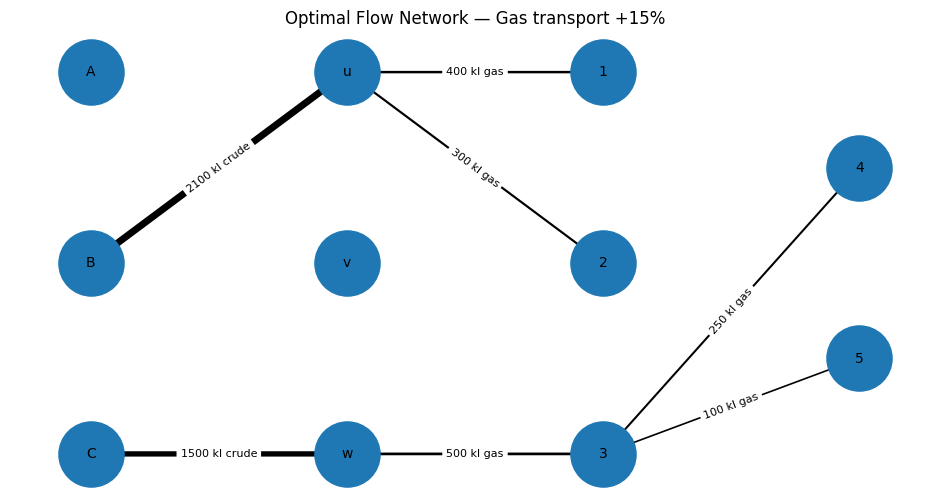

In [21]:
# ==========================================================
# 11. Flow diagrams by scenario
# ==========================================================

for result in results:
    if result["status"] == "Optimal":
        draw_solution_network(result)

## 12. Managerial Interpretation Template

After running the notebook, use the following template to interpret the results in the final report.

1. **Base case:** identify the cheapest route structure and which refineries are active.
2. **Refinery shutdown:** compare the objective value against the base case and explain how the network reroutes production.
3. **Port C limit:** evaluate whether the model was relying heavily on port C in the base case.
4. **Single private carrier:** identify whether Company 1 or Company 2 is selected and whether privatization changes refinery or crude-routing decisions.
5. **Route-by-route assignment:** compare savings against the single-carrier case.
6. **Company 1 bonus:** explain whether the bonus is large enough to change route assignments.
7. **Demand shock:** show how much the system cost increases when demand grows.
8. **Transportation cost stress:** evaluate the sensitivity of the optimal objective to external logistics cost increases.
9. **Environmental cap:** explain the trade-off between lower emissions and higher cost, if any.

A strong final conclusion should emphasize that the model converts a complex logistics decision into a transparent optimization framework, enabling cost, resilience, outsourcing, and sustainability trade-offs to be quantified.

## 13. Export Results

The following cell exports the scenario summary and detailed flows to Excel files. This makes it easier to reuse the results in the final written report.

In [22]:
# ==========================================================
# 13. Export outputs
# ==========================================================

output_path = "fuel_distribution_results.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    pd.DataFrame([r["costs"] for r in results]).to_excel(writer, sheet_name="scenario_summary", index=False)

    for result in results:
        # Excel sheet names must be <= 31 characters.
        sheet_prefix = result["scenario"][:20].replace(" ", "_").replace("+", "plus")
        if result["status"] == "Optimal":
            result["active_refineries_df"].to_excel(writer, sheet_name=f"{sheet_prefix}_ref", index=False)
            result["crude_df"].to_excel(writer, sheet_name=f"{sheet_prefix}_crude", index=False)
            result["gas_df"].to_excel(writer, sheet_name=f"{sheet_prefix}_gas", index=False)
            if not result["assignment_df"].empty:
                result["assignment_df"].to_excel(writer, sheet_name=f"{sheet_prefix}_assign", index=False)

print(f"Results exported to: {output_path}")

Results exported to: fuel_distribution_results.xlsx
